# 03a. EDA - Temporal Trends


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pathlib

# Load the refined dataset created in 02_data_preprocessing
PROCESSED_DATA_PATH = pathlib.Path("data/processed")
data_file = list(PROCESSED_DATA_PATH.glob("*_processed.parquet"))[0]
df = pd.read_parquet(data_file)

print(f"Loaded {len(df):,} records from {data_file.name}")

Loaded 3,077,538 records from sjpd_calls_2016_2026_processed.parquet


## 1. Daily and Hourly Volume Patterns

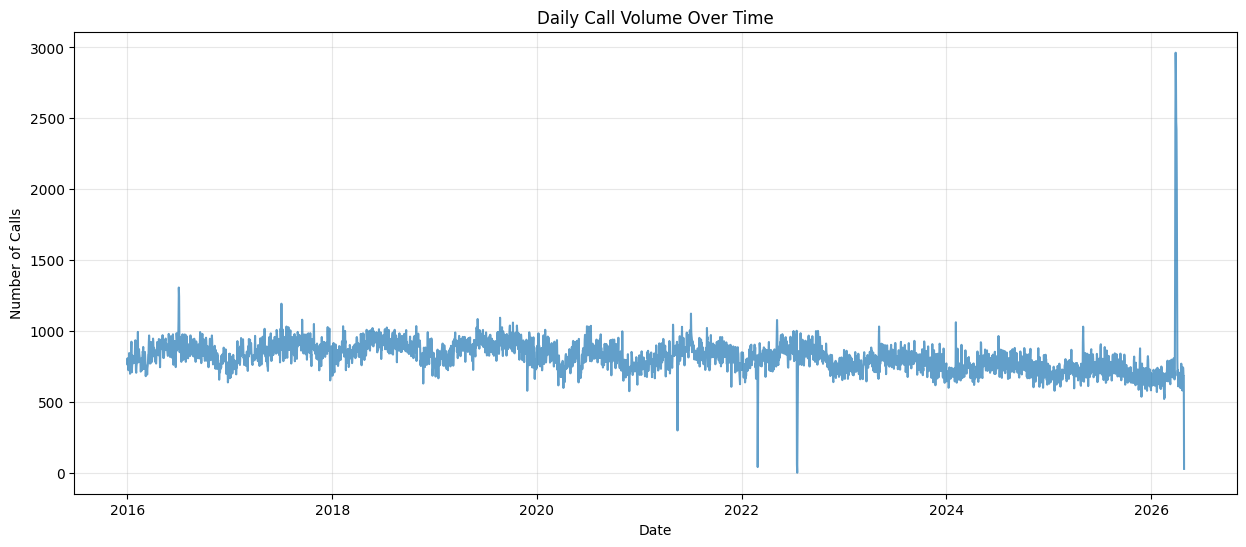

In [2]:
daily_calls = df.groupby(df["CDTS"].dt.date).size().reset_index(name="total_calls")
daily_calls["CDTS"] = pd.to_datetime(daily_calls["CDTS"])

plt.figure(figsize=(15, 6))
plt.plot(daily_calls["CDTS"], daily_calls["total_calls"], alpha=0.7)
plt.title("Daily Call Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Workload Heatmaps (Weekday vs Hour)

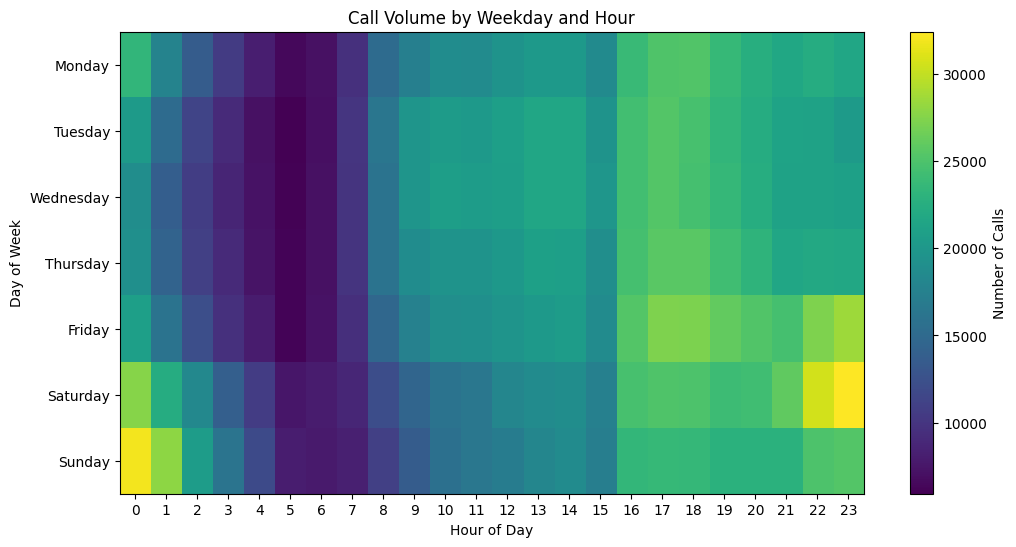

In [3]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

workload_heat = (
    df.groupby(["day_of_week", "hour"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(day_order)
)

plt.figure(figsize=(12, 6))
im = plt.imshow(workload_heat, aspect="auto", cmap="viridis")
plt.title("Call Volume by Weekday and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(range(24))
plt.yticks(range(7), day_order)
plt.colorbar(im, label="Number of Calls")
plt.show()

## 3. High-Level Summary Statistics

In [4]:
monthly_summary = df.groupby(["year", "month"]).size().unstack(fill_value=0)
display("Monthly Totals by Year:", monthly_summary)

busiest_day_row = daily_calls.loc[daily_calls["total_calls"].idxmax()]
print(f"\nBusiest Day: {busiest_day_row['CDTS'].date()} with {busiest_day_row['total_calls']:,} calls.")

'Monthly Totals by Year:'

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,24717,23345,25015,25633,27659,26558,28582,27121,26229,26352,23543,24456
2017,24014,23191,25909,25606,26604,26661,28356,27863,27600,27799,25510,27059
2018,25577,24347,26505,26389,29036,27906,28470,28411,27249,27496,25198,25780
2019,24827,22809,27378,27012,27263,28451,27808,28560,27743,28818,26194,25746
2020,26163,24893,24201,22982,25706,24548,26918,26333,25066,25331,22215,23121
2021,23435,21771,25530,24276,26138,26729,27172,26205,25584,26230,24832,24202
2022,23404,21332,25315,23553,27064,26030,23623,26737,26074,26065,22617,22715
2023,23549,21021,23440,23624,25346,24434,25499,24854,24046,24405,22524,23729
2024,21487,21464,23064,21315,23832,23145,24245,23537,22937,23575,21670,22237



Busiest Day: 2026-03-29 with 2,963 calls.
